### Customer Support Routing System with Specialized Departments using Sub-Graphs
- A LangGraph customer support system that classifies user queries and dispatches them to specialized sub-graphs
    - technical troubleshooting or billing/invoicing 
    - each running its own multi-step resolution workflow.

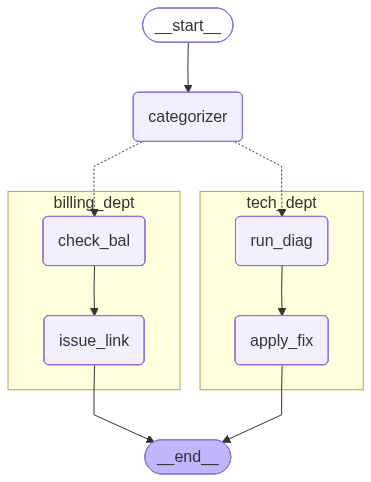

In [1]:
import os
from typing import List, Annotated
from operator import add
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# ═══════════════════════════════════════════════════════════════
# USE CASE: Customer Support Routing System
#
# A query comes in → parent graph classifies it → routes to the
# correct department (sub-graph) → department resolves it.
#
# Why sub-graphs? Each department has its OWN multi-step workflow
# and its OWN internal data. We don't want billing logic polluting
# the tech state, or vice versa. Sub-graphs give us isolation.
# ═══════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────────────────────
# 1. PARENT STATE — the "shared" state visible to everyone
# ─────────────────────────────────────────────────────────────
# This is what flows through the TOP-LEVEL graph. Sub-graphs can
# read fields from here if their own state has matching keys.
class SupportState(TypedDict):
    user_id: str
    query: str
    category: str 
    resolution_steps: Annotated[List[str], add]  # `add` = reducer; appends instead of overwriting

# ─────────────────────────────────────────────────────────────
# --- 2. SUB-GRAPH A: Technical Troubleshooting ---
# ─────────────────────────────────────────────────────────────
# Notice this sub-graph has its OWN state schema. Only the keys
# that overlap with SupportState (`query`, `resolution_steps`)
# get passed in/out automatically. `diagnostics_data` is private
# to this sub-graph — the parent never sees it.
class TechState(TypedDict):
    query: str
    diagnostics_data: List[str] 
    resolution_steps: Annotated[List[str], add]

def run_diagnostics_node(state: TechState): 
    print("--- [Sub-Graph: Tech] Running System Scan ---")
    return {"diagnostics_data": ["CPU Status: OK", "Memory: Clean"]}

def provide_troubleshooting_node(state: TechState):
    print("--- [Sub-Graph: Tech] Generating Fix Steps ---")
    return {"resolution_steps": ["Restarting service", "Clearing cache"]}

tech_builder = StateGraph(TechState)
# Use a name that is different from any key in TechState
tech_builder.add_node("run_diag", run_diagnostics_node) 
tech_builder.add_node("apply_fix", provide_troubleshooting_node) 

tech_builder.add_edge(START, "run_diag")
tech_builder.add_edge("run_diag", "apply_fix")
tech_builder.add_edge("apply_fix", END)
tech_subgraph = tech_builder.compile()

# ─────────────────────────────────────────────────────────────
# 3. SUB-GRAPH B — Billing & Invoicing
# ─────────────────────────────────────────────────────────────
# Same pattern as the tech sub-graph, but a different domain.
# `invoice_id` is private to this sub-graph; `user_id` and
# `resolution_steps` are shared with the parent
class BillingState(TypedDict):
    user_id: str
    invoice_found: bool
    resolution_steps: Annotated[List[str], add]

def check_balance_node(state: BillingState):
    print(f"--- [Sub-Graph: Billing] Checking balance for {state['user_id']} ---")
    return {"invoice_found": True}

def generate_invoice_node(state: BillingState):
    print("--- [Sub-Graph: Billing] Generating PDF Link ---")
    return {"resolution_steps": ["Invoice Link: https://billing.service/123"]}

billing_builder = StateGraph(BillingState)
billing_builder.add_node("check_bal", check_balance_node)
billing_builder.add_node("issue_link", generate_invoice_node)
billing_builder.add_edge(START, "check_bal")
billing_builder.add_edge("check_bal", "issue_link")
billing_builder.add_edge("issue_link", END)
billing_subgraph = billing_builder.compile()

# ─────────────────────────────────────────────────────────────
# 4. PARENT GRAPH — The Router
# ─────────────────────────────────────────────────────────────
# The parent's only job is to CLASSIFY the query and DISPATCH it.
# It does NOT solve the problem itself — that's the sub-graph's job.
def categorizer(state: SupportState):
    category = "technical" if "slow" in state["query"].lower() else "billing"
    print(f"--- [Parent] Routing query to {category} department ---")
    return {"category": category}

def router_logic(state: SupportState):
    if state["category"] == "technical":
        return "tech_dept"
    return "billing_dept"


# Build the parent graph, which references the two sub-graphs as nodes
builder = StateGraph(SupportState)

builder.add_node("categorizer", categorizer)
builder.add_node("tech_dept", tech_subgraph)       # ← sub-graph used as a node
builder.add_node("billing_dept", billing_subgraph) # ← sub-graph used as a node

builder.add_edge(START, "categorizer")

# Conditional edge: after categorizer runs, router_logic decides
# which department gets the query. The dict maps router_logic's
# return value → the actual node to go to.
builder.add_conditional_edges(
    "categorizer", 
    router_logic, 
    {"tech_dept": "tech_dept", "billing_dept": "billing_dept"}
)
builder.add_edge("tech_dept", END)
builder.add_edge("billing_dept", END)

graph = builder.compile()

# --- 5. VISUALIZATION ---
from IPython.display import Image, display
# use xray=1 to see sub-graphs boxes
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [2]:
# --- 6. EXECUTION ---
print("\n--- Running Tech Query ---")
graph.invoke({"user_id": "U123", "query": "My computer is very slow"})


--- Running Tech Query ---
--- [Parent] Routing query to technical department ---
--- [Sub-Graph: Tech] Running System Scan ---
--- [Sub-Graph: Tech] Generating Fix Steps ---


{'user_id': 'U123',
 'query': 'My computer is very slow',
 'category': 'technical',
 'resolution_steps': ['Restarting service', 'Clearing cache']}

In [3]:
# --- 7. EXECUTION ---
print("\n--- Running Bill Query ---")
graph.invoke({"user_id": "U456", "query": "Where can I download my last payment invoice?"})


--- Running Bill Query ---
--- [Parent] Routing query to billing department ---
--- [Sub-Graph: Billing] Checking balance for U456 ---
--- [Sub-Graph: Billing] Generating PDF Link ---


{'user_id': 'U456',
 'query': 'Where can I download my last payment invoice?',
 'category': 'billing',
 'resolution_steps': ['Invoice Link: https://billing.service/123']}